In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file = "College_qbr_data.csv"
data = pd.read_csv(file)
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2033 entries, 0 to 2032
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   season               2033 non-null   int64  
 1   week                 84 non-null     float64
 2   week_text            2033 non-null   object 
 3   player_id            2033 non-null   int64  
 4   player_uid           2033 non-null   object 
 5   player_guid          2033 non-null   object 
 6   name_first           2033 non-null   object 
 7   name_last            2033 non-null   object 
 8   name_display         2033 non-null   object 
 9   name_short           2033 non-null   object 
 10  age                  797 non-null    float64
 11  team_name            2033 non-null   object 
 12  team_short_name      2033 non-null   object 
 13  slug                 2033 non-null   object 
 14  team_id              2033 non-null   int64  
 15  team_uid             2033 non-null   o

In [ ]:
data = data.drop(columns=["week", "week_text", "player_id", "player_uid", "player_guid", "name_first", "name_last", "name_display", "name_short", "team_name", 
                   "team_id", "team_uid", "headshot_href", "week_type", "game_id", "game_date", "player_home_away", "score", "opp_team_id", 
                   "opp_team_name", "opp_team_short_name"])

data
print()

,season,age,team_short_name,slug,qbr_total,pts_added,qb_plays,epa_total,pass,run,exp_sack,penalty,qbr_raw,sack
0,2006,23.0,WVU,pat-white,90.5,72.9,370,76.1,37.7,45.0,-6.1,1.2,88.6,-7.6
1,2006,25.0,HAW,colt-brennan,85.8,126.4,690,127.5,125.2,15.4,-12.3,1.3,87.0,-14.8
2,2006,27.0,BYU,john-beck,83.4,66.5,517,72.7,80.7,0.0,-8.4,1.6,79.2,-9.7
3,2006,23.0,LSU,jamarcus-russell,82.1,47.0,428,54.7,65.2,1.3,-9.7,0.1,75.8,-11.8
4,2006,24.0,OSU,troy-smith,82.0,46.7,414,54.0,62.7,3.0,-9.3,-0.5,76.4,-11.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2028,2022,NaN,CONN,zion-turner,13.1,-9.5,36,-5.4,-5.3,-0.6,-0.3,0.8,6.1,-0.3
2029,2022,NaN,CIN,evan-prater,11.7,-7.1,28,-5.0,0.1,0.7,-4.7,0.0,6.7,-5.8
2030,2022,NaN,USU,cooper-legas,11.2,-5.4,26,-3.5,-1.7,0.6,-2.2,-0.1,10.5,-2.2
2031,2022,NaN,CCU,jarrett-guest,9.0,-4.1,22,-2.4,1.1,-0.6,-1.9,0.0,12.5,-2.8


In [72]:
team_names = data["team_short_name"].to_numpy()
num_teams = 0
incl_teams = []
freq_teams = []
for team in team_names:
    if not team in incl_teams:
        num_teams += 1
        incl_teams.append(team)
        freq_teams.append(1)
    else:
        index = incl_teams.index(team)
        freq_teams[index] += 1

freq_teams = np.array(freq_teams)

print(f"Number of teams: {num_teams}")
print(f"Average number of QBs per team: {np.mean(freq_teams)}")

Number of teams: 143
Average number of QBs per team: 14.216783216783217


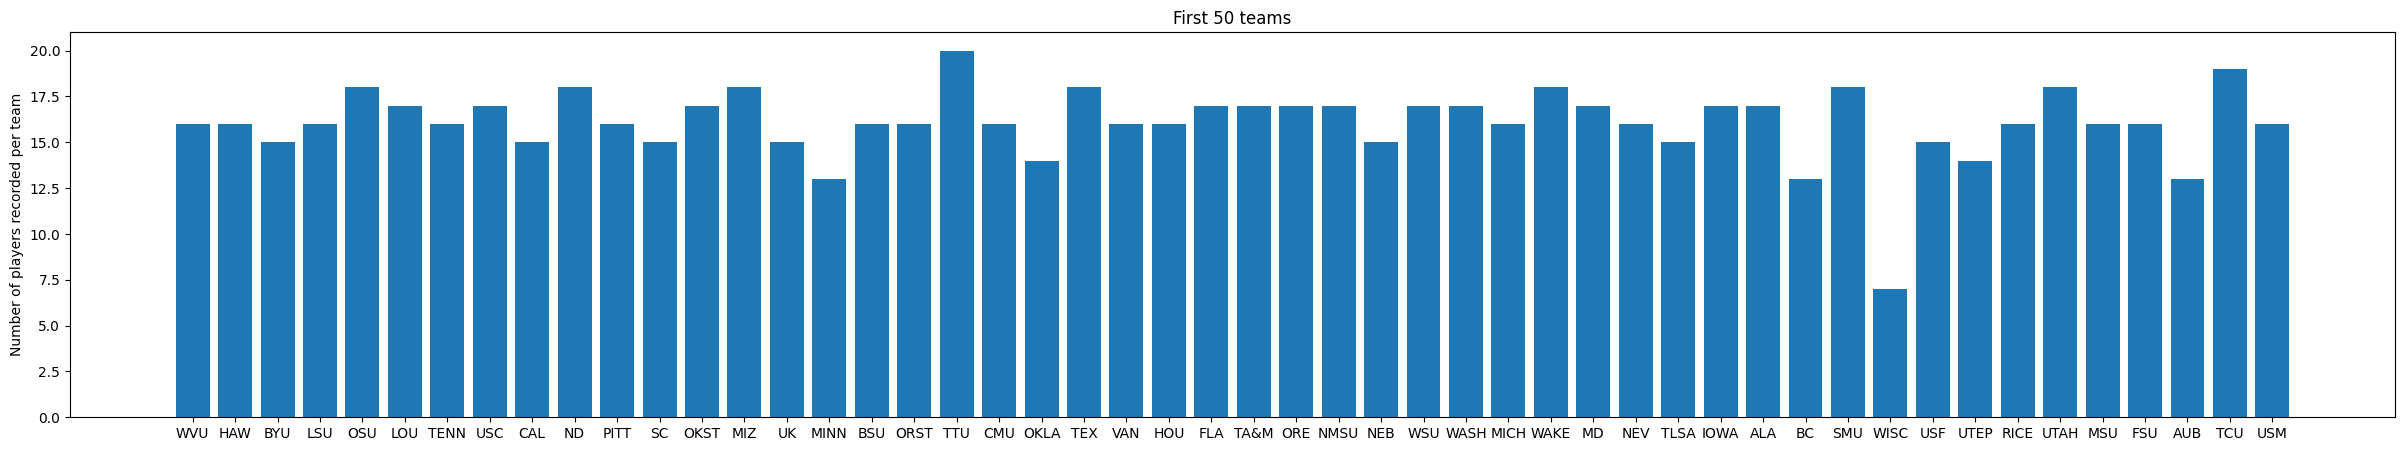

In [73]:
# Bar plots (split up)
fig = plt.figure(figsize=(30,5))
plt.bar(incl_teams[:50], freq_teams[:50])
plt.title("First 50 teams")
plt.ylabel("Number of players recorded per team")
plt.show()

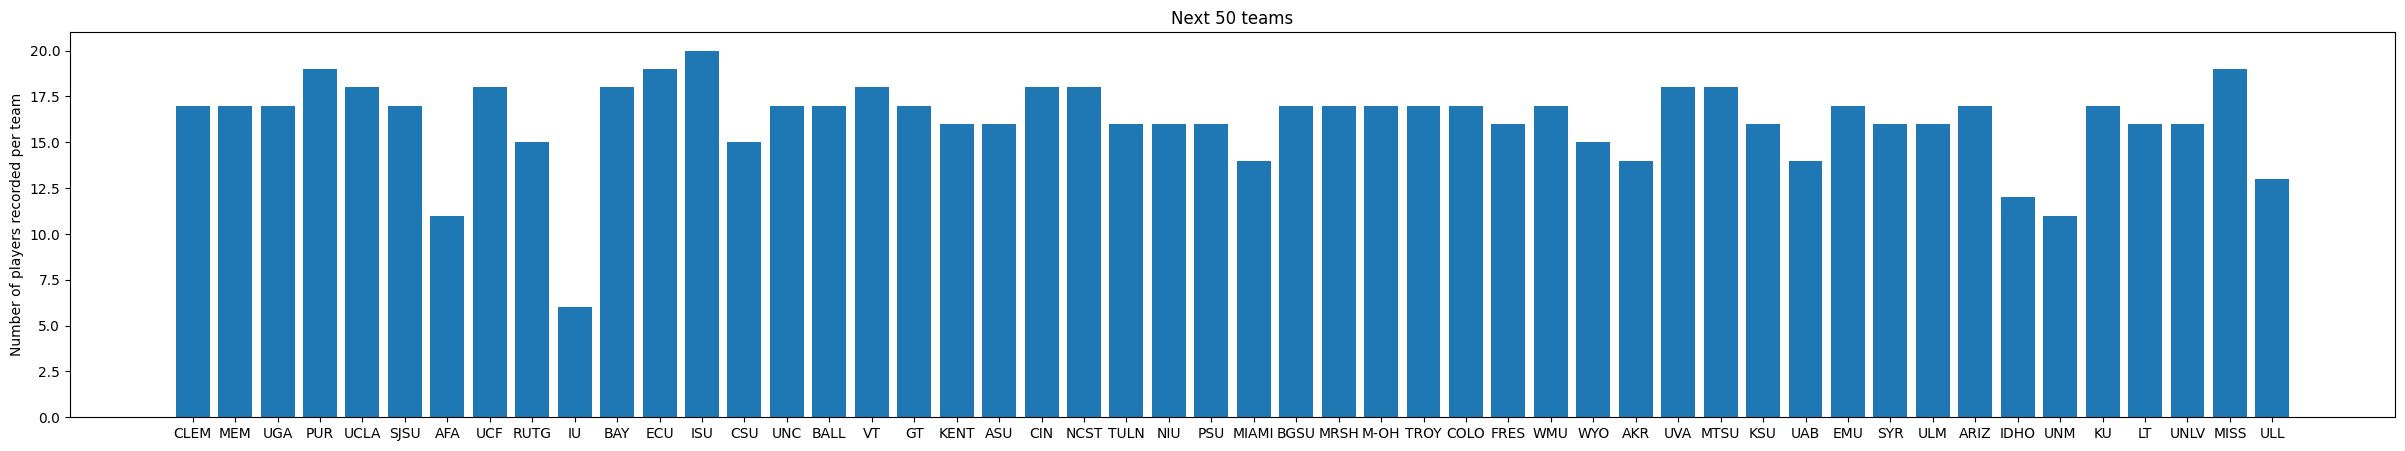

In [74]:
# Bar plots (split up)
fig = plt.figure(figsize=(30,5))
plt.bar(incl_teams[50:100], freq_teams[50:100])
plt.title("Next 50 teams")
plt.ylabel("Number of players recorded per team")
plt.show()

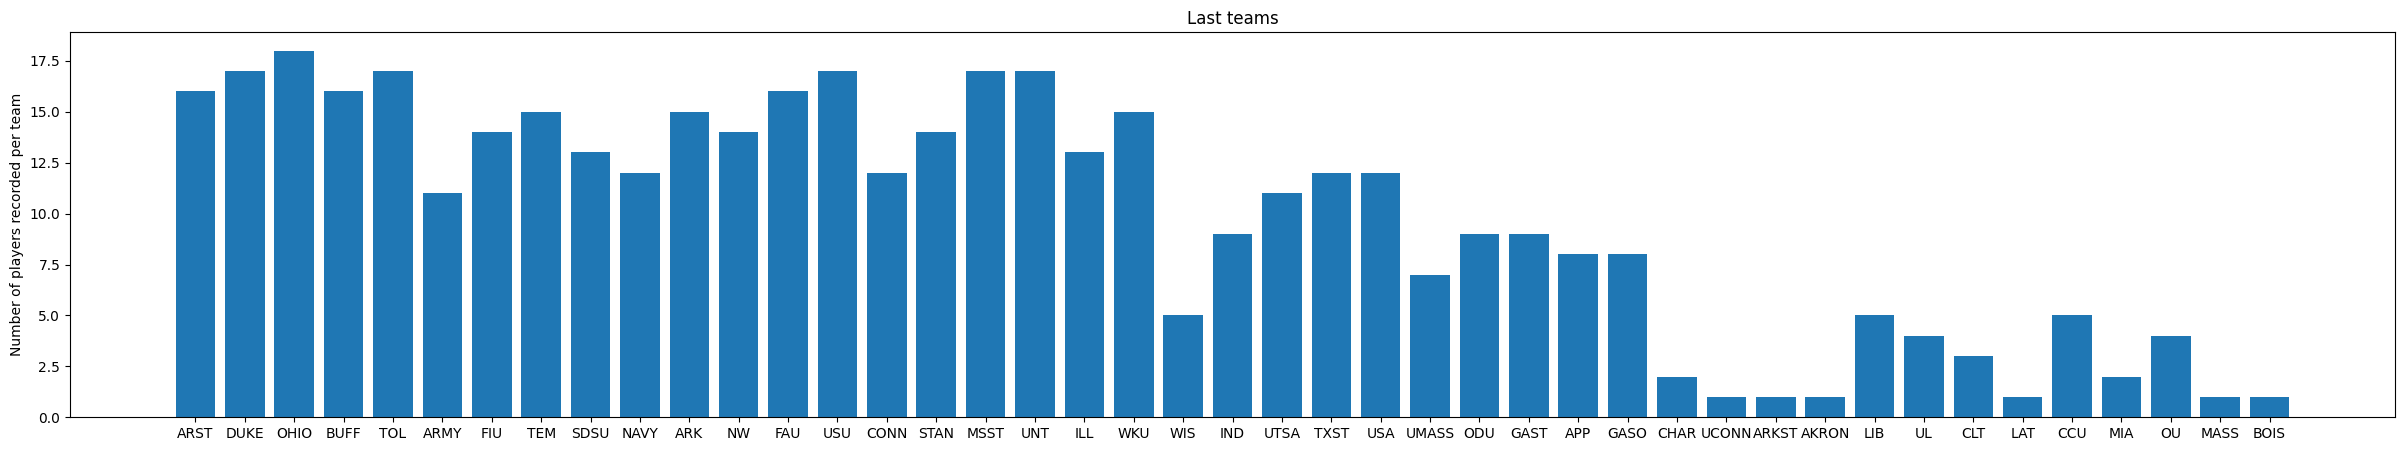

In [75]:
# Bar plots (split up)
fig = plt.figure(figsize=(30,5))
plt.bar(incl_teams[100:], freq_teams[100:])
plt.title("Last teams")
plt.ylabel("Number of players recorded per team")
plt.show()

In [78]:
player_names = data["slug"]
num_players = 0
incl_players = []
seasons_per_player = []

for player in player_names:
    if not player in incl_players:
        num_players += 1
        incl_players.append(player)
        seasons_per_player.append(1)
    else:
        index = incl_players.index(player)
        seasons_per_player[index] += 1
    
seasons_per_player = np.array(seasons_per_player)

print(f"Number of players: {num_players}")
print(f"Average number of seasons per players: {np.mean(seasons_per_player)}")
print(f"Max recorded seasons per player: {np.max(seasons_per_player)}")
print(f"Number of players for which only 1 season is recorded: {np.count_nonzero(seasons_per_player == 1)}")

Number of players: 1049
Average number of seasons per players: 1.9380362249761678
Max recorded seasons per player: 5
Number of players for which only 1 season is recorded: 445


In [85]:
age = np.array(data["age"])
age = age[~np.isnan(age)]


In [86]:
print(f"Min age: {np.min(age)}")
print(f"Max age: {np.max(age)}")

Min age: 2.0
Max age: 38.0


In [84]:
print(data[data["age"] == 2])

     season  age team_short_name             slug  qbr_total  pts_added  \
329    2008  2.0             SYR  cameron-dantley       32.0      -31.1   

     qb_plays  epa_total  pass  run  exp_sack  penalty  qbr_raw  sack  
329       326      -13.0   6.0 -2.4     -14.7      0.1     27.1 -16.7  


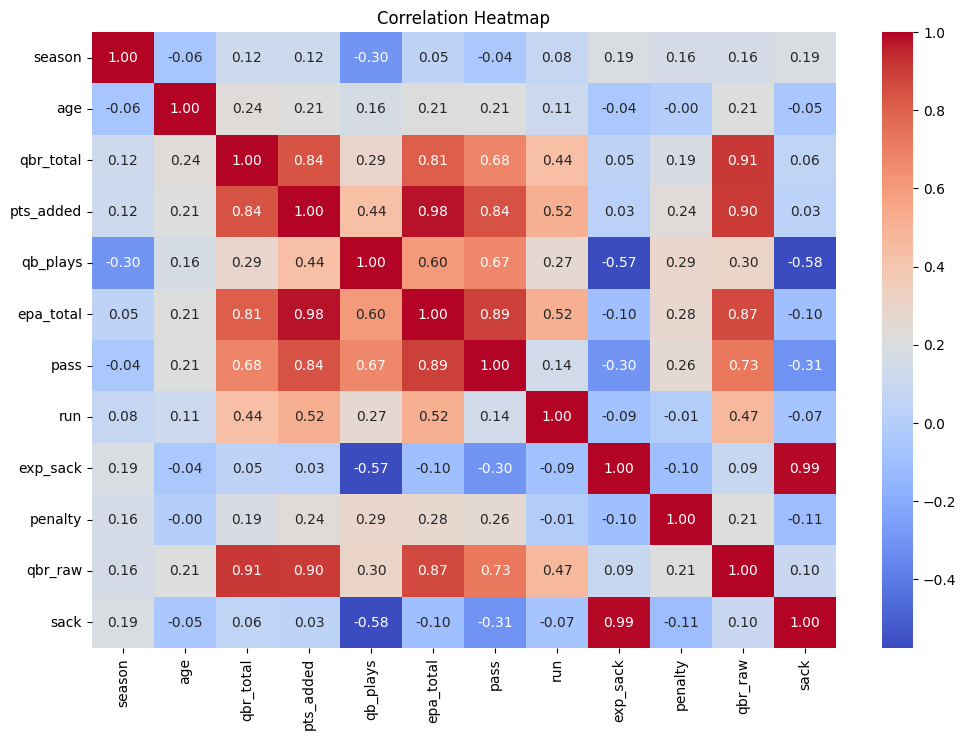

In [88]:
import seaborn as sns
#Correlation between the attributes

# Select only numeric columns
numeric_df = data.drop(columns=["team_short_name", "slug"])

# Calculate the correlation matrix
corr = numeric_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()